### _Event Display_

In [1]:
import sys, os, glob, yaml

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import pprint
import networkx as nx
import seaborn as sns
import trackml.dataset

In [4]:
import torch
from torch_geometric.data import Data
import itertools

### _Dataset_

In [5]:
# mu+mu- data (current)
input_dir = 'train_all'

In [6]:
# Find All Input Data Files (hits.csv, cells.csv, particles.csv, truth.csv)
all_files = os.listdir(input_dir)

# Extract File Prefixes (use e.g. xxx-hits.csv)
suffix = '-hits.csv'
file_prefixes = sorted(os.path.join(input_dir, f.replace(suffix, ''))
                       for f in all_files if f.endswith(suffix))

In [7]:
file_prefixes[:10]

['train_all/event0000000000',
 'train_all/event0000000001',
 'train_all/event0000000002',
 'train_all/event0000000003',
 'train_all/event0000000004',
 'train_all/event0000000005',
 'train_all/event0000000006',
 'train_all/event0000000007',
 'train_all/event0000000008',
 'train_all/event0000000009']

In [8]:
print("Total files: ", len(file_prefixes))

Total files:  1000


In [9]:
# test to load an event
event_prefix = file_prefixes[10]

hits, tubes, particles, truth = trackml.dataset.load_event(event_prefix)

# memory usage
mem_bytes = (hits.memory_usage(index=True).sum() 
             + tubes.memory_usage(index=True).sum() 
             + particles.memory_usage(index=True).sum() 
             + truth.memory_usage(index=True).sum())

print('{} memory usage {:.2f} MB'.format(os.path.basename(event_prefix), mem_bytes / 2**20))

event0000000010 memory usage 0.02 MB


In [10]:
hits.head()

,hit_id,x,y,z,volume_id,layer_id,module_id
0,1,16.618999,-6.565,35.0,9,0,72
1,2,17.493700,-7.070,35.0,9,1,180
2,3,18.368401,-6.565,35.0,9,2,295
3,4,19.243099,-7.070,35.0,9,3,415
4,5,20.117800,-7.575,35.0,9,4,541


In [11]:
tubes.head()

,hit_id,isochrone,depcharge,energyloss,volume_id,layer_id,module_id,skewed,sector_id
0,1,0.103051,9895810.0,9.89581,9,0,72,0,4
1,2,0.239589,17889800.0,17.88980,9,1,180,0,4
2,3,0.372083,11880900.0,11.88090,9,2,295,0,4
3,4,0.011489,10889500.0,10.88950,9,3,415,0,4
4,5,0.443323,5899680.0,5.89968,9,4,541,0,4


In [12]:
particles.head()

,particle_id,vx,vy,vz,px,py,pz,q,nhits,pdgcode,start_time,primary
0,6,0.328050,-0.306827,1.190180,0.052407,-0.083315,0.512553,1,3,2212,0.084214,1
1,7,0.328050,-0.306827,1.190180,0.115424,-0.073658,0.096347,-1,26,-211,0.084214,1
2,51,-1.696350,1.757400,10.255700,-0.295962,0.091899,0.593852,1,21,1000010020,0.492607,0
3,52,-1.696350,1.757400,10.255700,0.114053,0.171323,0.334603,1,26,211,0.492607,0
4,71,39.020199,29.678301,96.828201,-0.603024,0.088728,0.305656,1,16,2212,4.063850,0


In [13]:
truth.head()

,hit_id,tx,ty,tz,tpx,tpy,tpz,weight,particle_id
0,1,16.600000,-6.67526,13.6960,0.128811,-0.022309,0.092387,1.0,7
1,2,17.530701,-6.82668,14.3623,0.129212,-0.019643,0.092341,1.0,7
2,3,18.317499,-6.94053,14.9245,0.129299,-0.017577,0.092567,1.0,7
3,4,19.244900,-7.05354,15.5873,0.129561,-0.014556,0.092641,1.0,7
4,5,20.156200,-7.14775,16.2376,0.129876,-0.011725,0.092523,1.0,7


## _SttCSVReader_

In [14]:
from src import SttCSVReader

In [15]:
csv_reader = SttCSVReader(path=input_dir, noise=True, skewed=True)

### _1. Read Event_

In [16]:
data = csv_reader(1)

In [17]:
data.hits.head()

,hit_id,x,y,z,volume_id,layer_id,module_id,isochrone,skewed,sector_id,event_id
0,1,16.618999,-9.595,35.0,9,0,69,0.139763,0,3,1
1,2,17.493700,-9.090,35.0,9,1,178,0.198980,0,4,1
2,3,18.368401,-9.595,35.0,9,2,292,0.430639,0,4,1
3,4,19.243099,-9.090,35.0,9,3,413,0.210106,0,4,1
4,5,20.117800,-8.585,35.0,9,4,540,0.004633,0,4,1


In [18]:
data.hits.shape

(57, 11)

In [19]:
csv_reader = SttCSVReader(path=input_dir, noise=True, skewed=False)

In [20]:
data = csv_reader(1)

In [21]:
data.hits.head()

,hit_id,x,y,z,volume_id,layer_id,module_id,isochrone,skewed,sector_id,event_id,layer
0,1,16.618999,-9.595000,35.0,9,0,69,0.139763,0,3,1,0
1,28,5.248110,16.160000,35.0,9,0,101,0.343498,0,5,1,0
2,31,-16.618999,2.525000,35.0,9,0,24,0.062133,0,1,1,0
3,2,17.493700,-9.090000,35.0,9,1,178,0.198980,0,4,1,1
4,29,6.122800,16.665001,35.0,9,1,210,0.056950,0,5,1,1


In [22]:
data.hits.shape

(26, 12)

In [23]:
data.hits.layer_id.unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7, 16, 17, 18, 19], dtype=int32)

In [24]:
data.hits.layer.unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [25]:
data.event_file

'/home/adeak977/current/3_deeptrkx/ctd2022p/train_all/event0000000001'

In [26]:
data.event.head()

,hit_id,x,y,z,volume_id,layer_id,module_id,isochrone,skewed,sector_id,...,start_time,primary,pt,peta,r,phi,eta,r3,absZ,tpt
0,1,16.618999,-9.595000,35.0,9,0,69,0.139763,0,3,...,0.116657,1.0,0.087834,0.187725,19.189976,-0.523600,1.361974,39.915600,35.0,0.038709
1,28,5.248110,16.160000,35.0,9,0,101,0.343498,0,5,...,0.116657,1.0,0.091527,2.315381,16.990829,1.256782,1.470122,38.906147,35.0,0.069417
2,31,-16.618999,2.525000,35.0,9,0,24,0.062133,0,1,...,0.281485,1.0,0.107784,1.178240,16.809723,2.990811,1.479773,38.827396,35.0,0.106098
3,2,17.493700,-9.090000,35.0,9,1,178,0.198980,0,4,...,0.116657,1.0,0.087834,0.187725,19.714401,-0.479217,1.338408,40.170357,35.0,0.038036
4,29,6.122800,16.665001,35.0,9,1,210,0.056950,0,5,...,0.116657,1.0,0.091527,2.315381,17.754181,1.218701,1.430756,39.245522,35.0,0.068288


In [27]:
data.particles

,particle_id,vx,vy,vz,px,py,pz,q,nhits,pdgcode,start_time,primary,pt,peta
0,5,-0.289760,-0.110082,6.09407,-0.107358,-0.009571,0.158487,1,27,211,0.281485,1,0.107784,1.178240
1,6,0.159734,0.060684,1.36980,0.002950,0.091480,0.459012,1,3,2212,0.116657,1,0.091527,2.315381
2,7,0.159734,0.060684,1.36980,0.052510,-0.070410,0.016586,-1,15,-211,0.116657,1,0.087834,0.187725


### _2. Event Display_

In [28]:
from src import Draw_Reader_Event

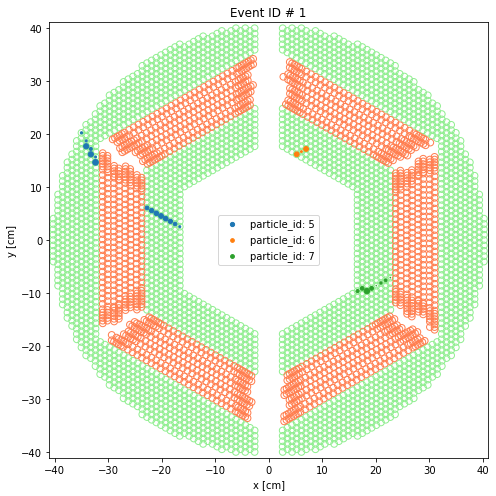

In [31]:
Draw_Reader_Event(csv_reader(1),figsize=(7,7),save_fig=False);

In [30]:
# for e in range(100):
#    data = csv_reader(e)
#    Draw_Reader_Event(data,figsize=(10, 10),save_fig=True);